/tmp/ipykernel_1894312/877166429.py:109: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ert = torch.tensor(create_consistent_layered_tensor(),dtype=torch.float32, device=device)


torch.Size([100, 100, 80]) torch.Size([100, 80])


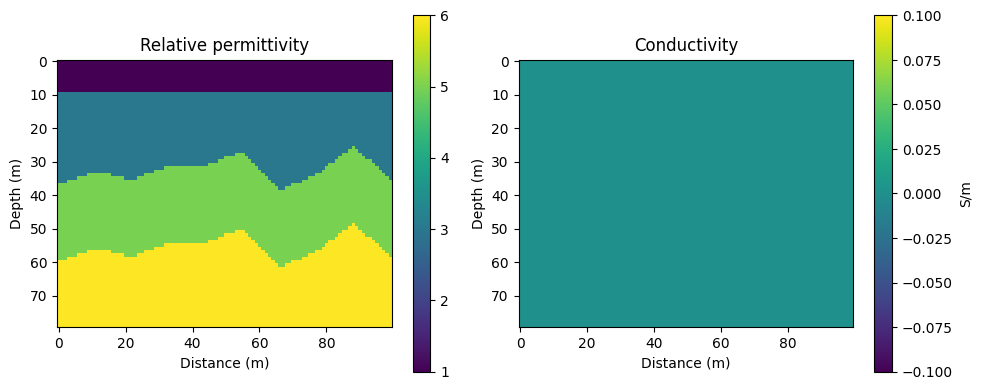

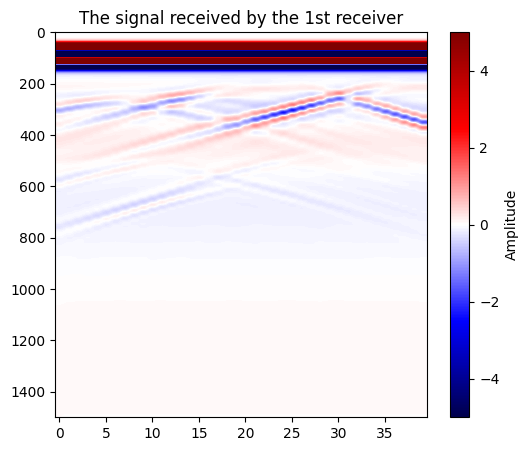

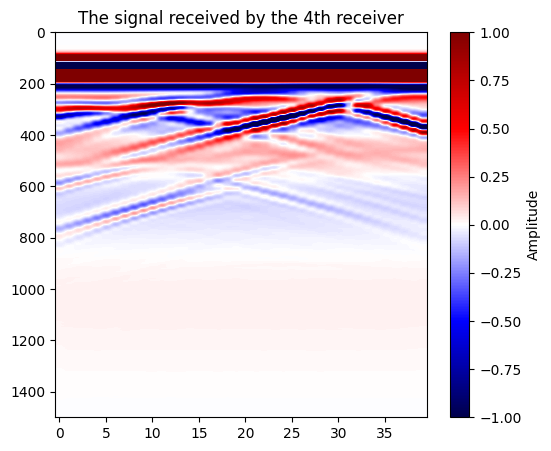

In [1]:
import DeepGPR
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from skimage import filters
import time

# Set up the parameters and models
torch.cuda.set_device(4)  # Ensure that the GPU is being used
device=torch.device("cuda")
dx=0.02
dt=3e-11
nt=1500

nshots=40

source_location=torch.zeros((40,1,3),device=device,dtype=torch.int)
source_location[:,0,1]=torch.arange(10, 90, 2)
source_location[:,0,0]=35
source_location[:,0,2]=9

receiver_location=torch.zeros((40,5,3),device=device,dtype=torch.int)
receiver_location[:,:,1]=torch.arange(11, 91, 2).repeat(5,1).T
receiver_location[:,0,0]=15
receiver_location[:,1,0]=25
receiver_location[:,2,0]=35
receiver_location[:,3,0]=45
receiver_location[:,4,0]=65
receiver_location[:,:,2]=9


freq=5e8
peak_time = 1 / freq
source_amplitudes = torch.zeros((1,nt,1),device=device)
source_amplitudes[0,:,0]=DeepGPR.ricker(freq, nt, dt, peak_time).to(device)

# def create_consistent_layered_tensor():
#     torch.manual_seed(42)
#     Nx, Ny, Nz = 100, 100, 80
#     tensor = torch.ones((Nx, Ny, Nz), dtype=torch.int32)
#     base_z2 = 33
#     base_z3 = 56
#     low_res_noise = torch.randn(1, 1, 10, 10)
#     smooth_noise = F.interpolate(low_res_noise, size=(Nx, Ny), mode='bicubic', align_corners=True).squeeze()
#     amplitude = 3.0
#     shared_fluctuation = (smooth_noise / smooth_noise.std()) * amplitude
#     interface_1_2 = base_z2 + shared_fluctuation
#     interface_2_3 = base_z3 + shared_fluctuation
#     interface_1_2 = interface_1_2.unsqueeze(-1)
#     interface_2_3 = interface_2_3.unsqueeze(-1)
#     Z = torch.arange(Nz).view(1, 1, Nz)
#     mask1 = (Z >= 10) & (Z < interface_1_2)
#     tensor[mask1] = 3
#     mask2 = (Z >= interface_1_2) & (Z < interface_2_3)
#     tensor[mask2] = 5
#     mask3 = (Z >= interface_2_3)
#     tensor[mask3] = 6

#     return tensor


def create_consistent_layered_tensor():
    torch.manual_seed(32)
    Nx, Ny, Nz = 100, 100, 80
    
    # 默认背景设为 1 (这意味着 Z 在 0~9 的空气层/表层默认值为 1)
    tensor = torch.ones((Nx, Ny, Nz), dtype=torch.int32)
    
    base_z2 = 33
    base_z3 = 56
    
    # --- 核心修改：生成一维噪声并沿 X 轴扩展 ---
    # 1. 生成 1D 的低分辨率纯随机噪声
    low_res_noise = torch.randn(1, 1, 10)
    
    # 2. 使用线性插值将其放大到 Ny 的尺寸（因为是在 Y 方向起伏）
    smooth_noise_1d = F.interpolate(low_res_noise, size=Ny, mode='linear', align_corners=True).squeeze()
    
    # 3. 将 1D 噪声 (Ny,) 扩展为 2D (Nx, Ny)
    # unsqueeze(0) 将其变为 (1, Ny)，expand 复制 Nx 次，使得所有 X 坐标下的波动完全一样
    smooth_noise = smooth_noise_1d.unsqueeze(0).expand(Nx, Ny)
    
    # 注：如果你实际想要的是“所有 Y 切面一样（X-Z 平面保持一致）”，
    # 请将上面的 size=Ny 改为 size=Nx，并将扩展方式改为 unsqueeze(1).expand(Nx, Ny)
    # ------------------------------------------
    
    amplitude = 3.0
    shared_fluctuation = (smooth_noise / smooth_noise.std()) * amplitude
    
    interface_1_2 = base_z2 + shared_fluctuation
    interface_2_3 = base_z3 + shared_fluctuation
    
    interface_1_2 = interface_1_2.unsqueeze(-1)
    interface_2_3 = interface_2_3.unsqueeze(-1)
    
    Z = torch.arange(Nz).view(1, 1, Nz)
    
    mask1 = (Z >= 10) & (Z < interface_1_2)
    tensor[mask1] = 3
    
    mask2 = (Z >= interface_1_2) & (Z < interface_2_3)
    tensor[mask2] = 5
    
    mask3 = (Z >= interface_2_3)
    tensor[mask3] = 6

    return tensor

ert = torch.tensor(create_consistent_layered_tensor(),dtype=torch.float32, device=device)
er_2d = ert[50, :, :]
set = torch.zeros_like(ert, device=device,dtype=torch.float32)
se_2d = set[50, :, :]

print(ert.shape, er_2d.shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  
im1 = axes[0].imshow(er_2d.cpu().numpy().T,
                     cmap='viridis',
                     interpolation='nearest',
                     aspect='equal')
cbar1 = plt.colorbar(im1, ax=axes[0])
axes[0].set_title('Relative permittivity')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Depth (m)')

im2 = axes[1].imshow(se_2d.cpu().numpy().T,
                     cmap='viridis',
                     interpolation='nearest',
                     aspect='equal')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('S/m')
axes[1].set_title('Conductivity')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Depth (m)')

plt.tight_layout()
plt.show()

pershot=2
#Forward modeling
r_obs_list = []
for i in range(nshots//pershot):
    r = DeepGPR.compute(
        device=device, dx=dx, dt=dt, 
        source_amplitudes=source_amplitudes,
        source_location=source_location[i*pershot:(i+1)*pershot,:,:], 
        receiver_location=receiver_location[i*pershot:(i+1)*pershot,:,:], 
        er=ert, se=set,model_gradient_sampling_interval=3
    )
    r_obs_list.append(r[-1])
r_obs = torch.cat(r_obs_list, dim=0)


plt.figure(figsize=(6, 5)) 
im = plt.imshow(r_obs[:,:,1].detach().cpu().numpy().T, cmap='seismic', origin='upper',aspect='auto',vmax=5,vmin=-5)
plt.colorbar(im, label='Amplitude') 
plt.title("The signal received by the 1st receiver") 
plt.show()

plt.figure(figsize=(6, 5)) 
im = plt.imshow(r_obs[:,:,4].detach().cpu().numpy().T, cmap='seismic', origin='upper',aspect='auto',vmax=1,vmin=-1)
plt.colorbar(im, label='Amplitude') 
plt.title("The signal received by the 4th receiver") 
plt.show()





In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt



In [3]:
import torch 

a=torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)
print(a.shape)
b=a.repeat(1,2)
print(b.shape)
print(b)

torch.Size([2, 3])
torch.Size([2, 6])
tensor([[1., 2., 3., 1., 2., 3.],
        [4., 5., 6., 4., 5., 6.]])
